In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from functions import F_P, GradientKernel,KernelGradientDiscrepancy
import jax_kernels as ker
from normalizing_flow import NormalizingFlow
import functions as f

import jax
from jax import random

In [2]:
device_name = "cpu"

In [3]:
c = 1
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))

def q_0(x):
    return jnp.exp(-jnp.linalg.norm(x)**2/2) #/ jnp.sqrt((2 *jnp.pi)**d)

def v(X):
    return -1/4 * jnp.linalg.norm(X, axis=1)**2 

def L(X):
    return jnp.mean(v(X))

k = jit(k)
q_0 = jit(q_0)
v = jit(v)
L = jit(L)


In [4]:
from jax import grad, random,vmap,tree_util
from jax.flatten_util import ravel_pytree

def init_params(key, d, hidden_dim):
    rng1, rng2,rng3,rng4 = random.split(key,4)
    params = {
        'W1': (random.uniform(rng1, (hidden_dim, d))) * 10.0,
        'b1': random.normal(rng4, (hidden_dim,)),
        'W2': (random.uniform(rng2, (d, hidden_dim))) * 10.0,
        'b2': random.normal(rng3, (d,)) 
    }
    return params

@jit
def forward(params, w):
    h = jnp.tanh(jnp.dot(params['W1'], w) + params['b1'])  # hidden layer
    y = jnp.dot(params['W2'], h) + params['b2']             # scalar output
    return y.squeeze()

In [5]:
d = 2 
hidden_dim = 2
key = random.PRNGKey(0)
params = init_params(key, d, hidden_dim)  
flat_params, unravel_fn = ravel_pytree(params)

def model(theta,W):
    param = unravel_fn(theta)
    return vmap(lambda w : forward(param, w))(W)

NF = NormalizingFlow(q_0,L,k,model)

In [11]:
theta0 = flat_params
W0 = random.normal(random.PRNGKey(2), (1000, d))
X0 = model(theta0, W0)
eta = 0.01
T = 1000

theta_fin = NF.run(theta0,eta,T,d,n_sim=100)[-1]
W_fin = random.normal(random.PRNGKey(1), (1000, d))
X_fin = model(theta_fin, W_fin)

3.1311078
3.1310852
3.1309261
3.1309533
3.1309736
3.1303267
3.1299546
3.1294515
3.12944
3.1288633
3.1288269
3.128789
3.1285002
3.1288757
3.1288311
3.128263
3.1285732
3.1280737
3.128103
3.1274397
3.1270008
3.1270514
3.1266825
3.1264062
3.1260629
3.125718
3.1256914
3.12496
3.1248794
3.1251037
3.124979
3.1245832
3.1241794
3.1244395
3.1237454
3.123732
3.1235764
3.1234233
3.1235316
3.1233227
3.123177
3.122739
3.1222494
3.1220198
3.1223311
3.1223724
3.1214826
3.1216717
3.1216798
3.1209562
3.1210525
3.1206334
3.1200378
3.119211
3.1193914
3.118508
3.11807
3.1174197
3.1171737
3.11688
3.1163046
3.1159384
3.1154807
3.1157293
3.1149805
3.114947
3.1145918
3.114402
3.114119
3.1142123
3.1139832
3.1137617
3.1130993
3.1127567
3.1127274
3.1116602
3.1116376
3.111983
3.111335
3.1112368
3.1109364
3.1108882
3.110453
3.110143
3.1094966
3.1095135
3.1089246
3.108914
3.1087878
3.1087906
3.1084898
3.1084046
3.108241
3.107993
3.1081238
3.1072736
3.107033
3.1071022
3.106359
3.1061113
3.106216
3.105683
3.105128
3.1

Text(0.5, 1.0, 'Initial distribution before training')

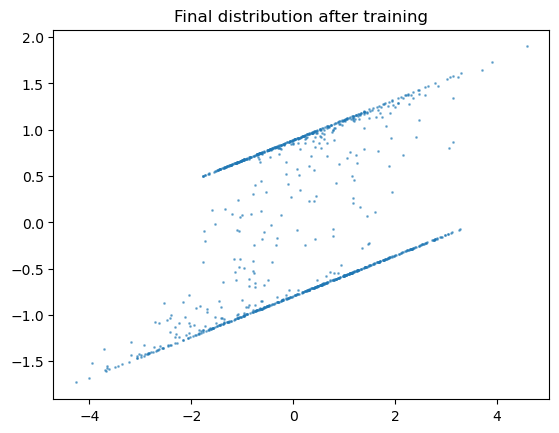

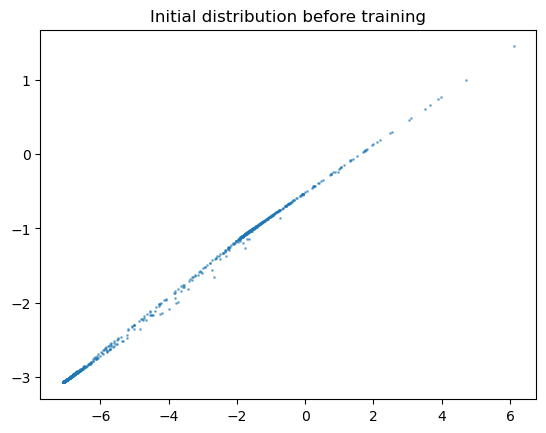

In [12]:
plt.scatter(X_fin[:, 0], X_fin[:, 1], s=1, alpha=0.5)
plt.title("Final distribution after training")
plt.figure()
plt.scatter(X0[:, 0], X0[:, 1], s=1, alpha=0.5)
plt.title("Initial distribution before training")